# ARTI308 - Machine Learning Lab 6


### 1. Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style='whitegrid')

### 2. Load and Prepare Dataset


In [4]:
df = pd.read_csv('Ecommerce_Customers.csv')

# Drop non-numeric columns not useful for regression
df_clean = df.drop(columns=['Email', 'Address', 'Avatar'])

print("Data loaded and preprocessed.")
print(df_clean.head())

Data loaded and preprocessed.
   Avg. Session Length  Time on App  Time on Website  Length of Membership  \
0            34.497268    12.655651        39.577668              4.082621   
1            31.926272    11.109461        37.268959              2.664034   
2            33.000915    11.330278        37.110597              4.104543   
3            34.305557    13.717514        36.721283              3.120179   
4            33.330673    12.795189        37.536653              4.446308   

   Yearly Amount Spent  
0           587.951054  
1           392.204933  
2           487.547505  
3           581.852344  
4           599.406092  


### Task 1: Explore the Data


In [5]:
print(df_clean.info())
print("\n")
print(df_clean.describe())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Avg. Session Length   500 non-null    float64
 1   Time on App           500 non-null    float64
 2   Time on Website       500 non-null    float64
 3   Length of Membership  500 non-null    float64
 4   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5)
memory usage: 19.7 KB
None


       Avg. Session Length  Time on App  Time on Website  \
count           500.000000   500.000000       500.000000   
mean             33.053194    12.052488        37.060445   
std               0.992563     0.994216         1.010489   
min              29.532429     8.508152        33.913847   
25%              32.341822    11.388153        36.349257   
50%              33.082008    11.983231        37.069367   
75%              33.711985    12.753850        37.716432   
max              36.13

### Task 2: Exploratory Data Analysis (EDA)


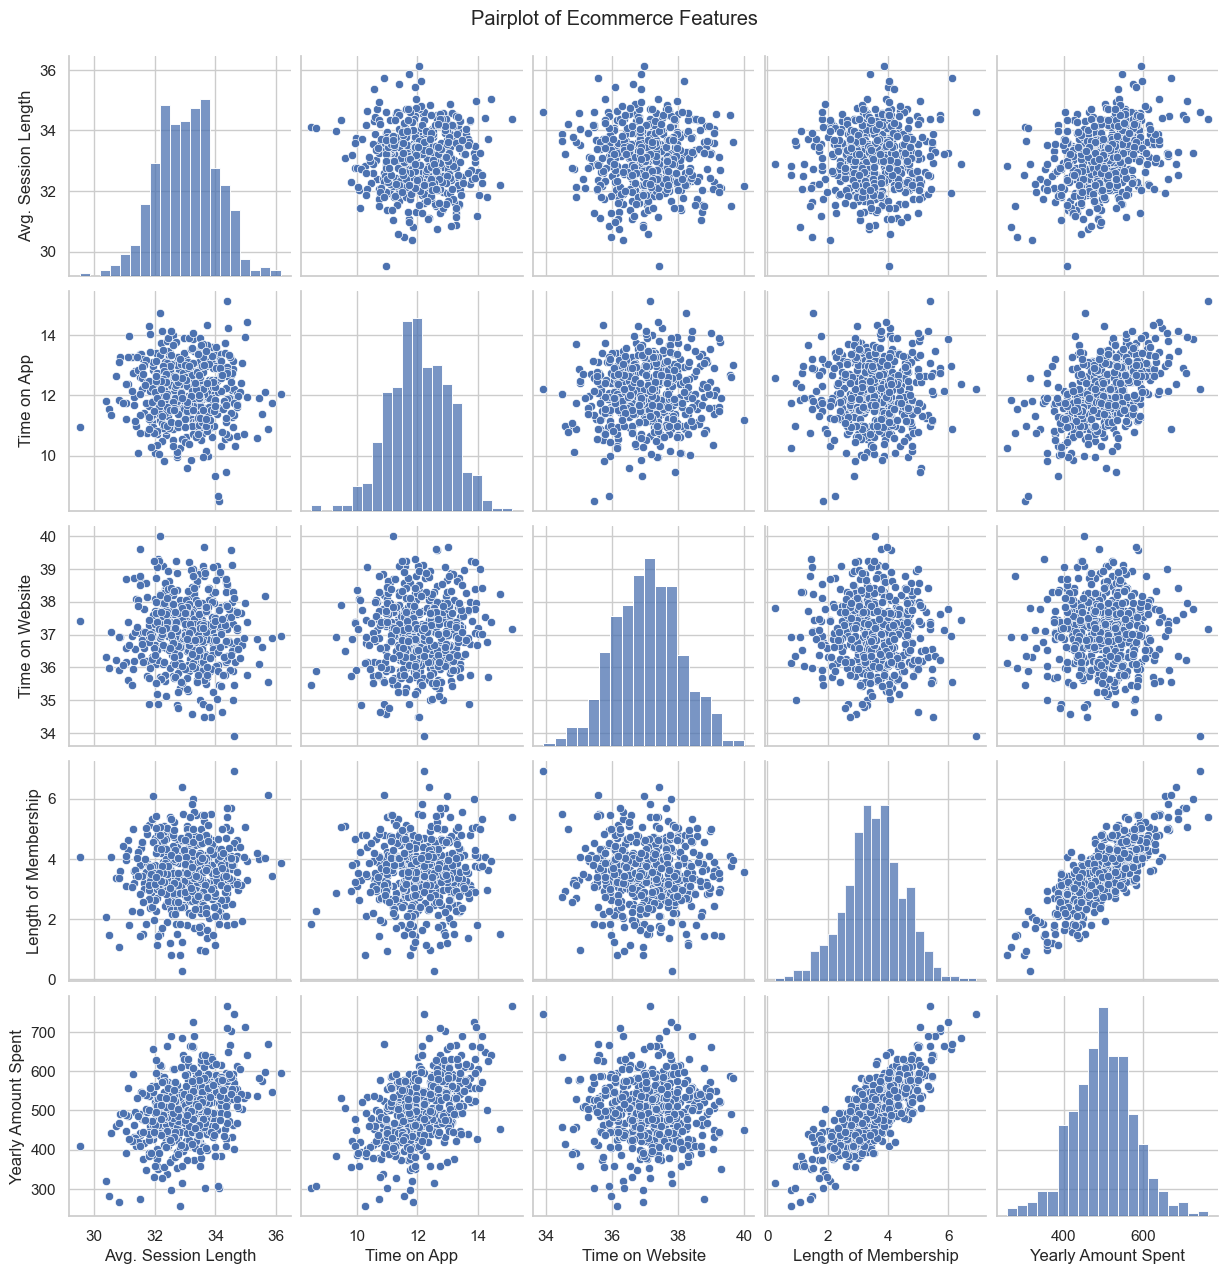

In [6]:
# Pairplot to visualize feature relationships
sns.pairplot(df_clean)
plt.suptitle('Pairplot of Ecommerce Features', y=1.02)
plt.show()

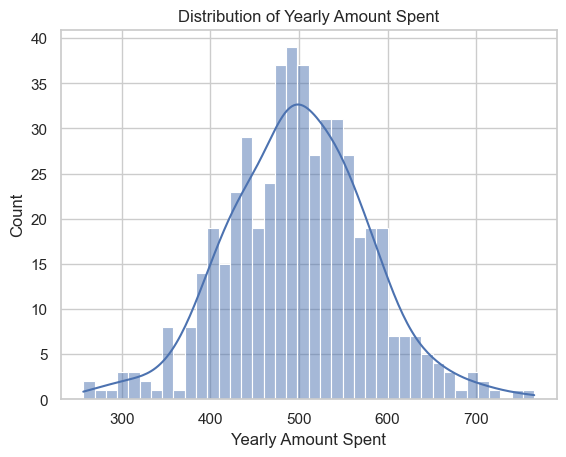

In [7]:
# Distribution of target variable
sns.histplot(df_clean['Yearly Amount Spent'], bins=40, kde=True)
plt.title('Distribution of Yearly Amount Spent')
plt.show()

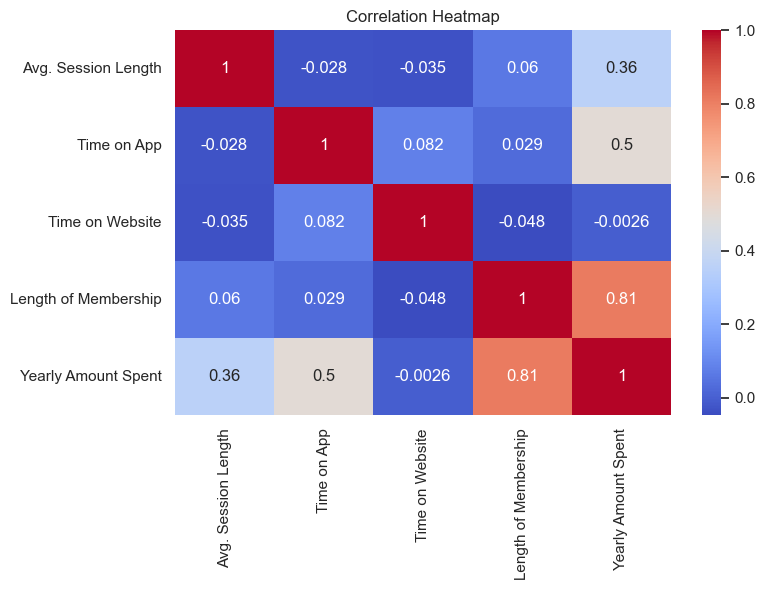

In [8]:
# Correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Task 3: Prepare Features and Target


In [9]:
features = ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']
X = df_clean[features]
y = df_clean['Yearly Amount Spent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 300
Test set size: 200


### Task 4: Train the Linear Regression Model


In [10]:
lm = LinearRegression()
lm.fit(X_train, y_train)

# Coefficients
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
print("Model Coefficients:")
print(coeff_df)
print(f"\nIntercept: {lm.intercept_:.4f}")

Model Coefficients:
                      Coefficient
Avg. Session Length     25.691540
Time on App             37.892600
Time on Website          0.560581
Length of Membership    61.648594

Intercept: -1045.1152


### Final Evaluation Report


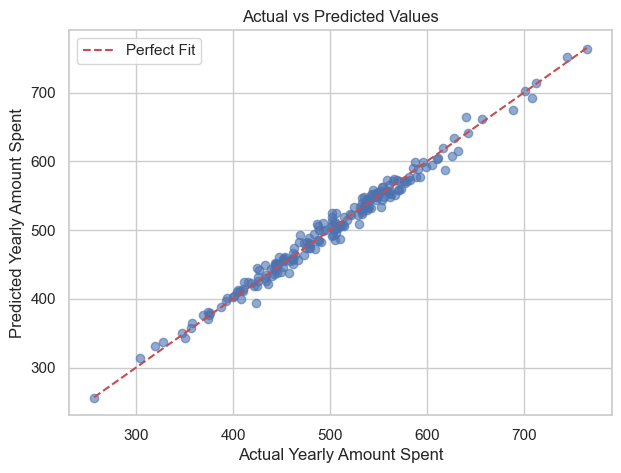

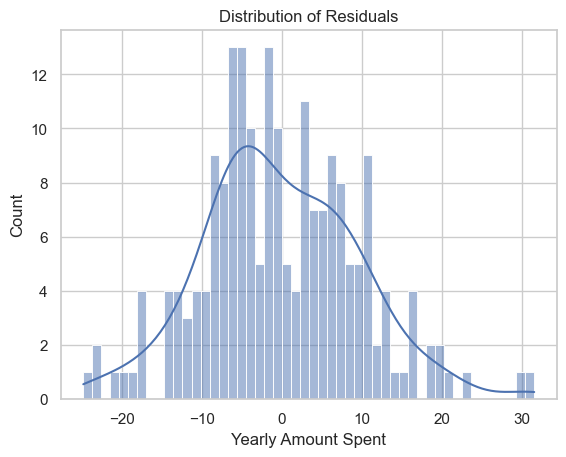

MAE  : 7.7427
MSE  : 93.8330
RMSE : 9.6867
R²   : 0.9855


In [11]:
predictions = lm.predict(X_test)

# Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')
plt.xlabel('Actual Yearly Amount Spent')
plt.ylabel('Predicted Yearly Amount Spent')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()

# Residuals
sns.histplot((y_test - predictions), bins=50, kde=True)
plt.title('Distribution of Residuals')
plt.show()

# Metrics
mae  = mean_absolute_error(y_test, predictions)
mse  = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, predictions)

print(f'MAE  : {mae:.4f}')
print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R\u00b2   : {r2:.4f}')